# ML Clasico



### Introducción

El objetivo es construir un pipeline de Machine Learning clásico que sirva como baseline para comparar con modelos de Deep Learning en futuros análisis.

La métrica prioritaria será el **recall de la clase PNEUMONIA**, ya que en un contexto clínico es crucial minimizar los falsos negativos (pacientes enfermos clasificados como sanos)."

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from skimage.feature import hog
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, RocCurveDisplay)
import warnings
warnings.filterwarnings('ignore')

CLASSES = ["NORMAL", "PNEUMONIA"]

In [ ]:
# CARGAR DATOS 
from google.colab import drive
import zipfile

drive.mount('/content/drive')

# Ajusta la ruta a donde lo hayas guardado en Drive
ZIP_PATH = "/content/drive/MyDrive/chest_xray_npy.zip"

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall("/content/chest_xray_npy")

print(" Archivos descomprimidos")

Mounted at /content/drive
 Archivos descomprimidos


In [ ]:
SAVE_DIR = "/content/chest_xray_npy"

X_train = np.load(f"{SAVE_DIR}/X_train.npy")  # (N, 224, 224) float32 0-1
y_train = np.load(f"{SAVE_DIR}/y_train.npy")
X_val   = np.load(f"{SAVE_DIR}/X_val.npy")
y_val   = np.load(f"{SAVE_DIR}/y_val.npy")
X_test  = np.load(f"{SAVE_DIR}/X_test.npy")
y_test  = np.load(f"{SAVE_DIR}/y_test.npy")

print(f"Train : {X_train.shape} | Val : {X_val.shape} | Test : {X_test.shape}")

Train : (5216, 224, 224) | Val : (16, 224, 224) | Test : (624, 224, 224)


### 1. Extracción de características (HOG)


Utilizamos el descriptor **Histogram of Oriented Gradients (HOG)** para extraer características relevantes de las imágenes.
HOG es ideal para este caso porque captura gradientes y estructuras locales, lo que es útil para detectar patrones en imágenes de rayos X.

Dado que las imágenes tienen una resolución de 224x224, el número de características generadas por HOG será elevado.
Esto nos permitirá capturar información detallada, pero también requerirá técnicas de reducción de dimensionalidad más adelante.


In [ ]:
def extract_hog(X, desc=""):
    features = []
    for img in tqdm(X, desc=f"HOG {desc}"):
        f = hog(img,
                orientations=9,
                pixels_per_cell=(16, 16),   # celdas más grandes → menos ruido
                cells_per_block=(2, 2),
                block_norm='L2-Hys')
        features.append(f)
    return np.array(features)

X_train_hog = extract_hog(X_train, "train")
X_val_hog   = extract_hog(X_val,   "val")
X_test_hog  = extract_hog(X_test,  "test")

print(f"\nShape HOG train: {X_train_hog.shape}")
print(f"Cada imagen → {X_train_hog.shape[1]} features")

HOG test: 100%|██████████| 624/624 [00:04<00:00, 125.08it/s]


Shape HOG train: (5216, 6084)
Cada imagen → 6084 features


### 2. Normalización + PCA

Antes de aplicar modelos de Machine Learning, normalizamos las características con **StandardScaler** para garantizar que todas las variables tengan la misma escala.

Posteriormente, utilizamos **PCA (Análisis de Componentes Principales)** para reducir la dimensionalidad del dataset.

Esto es crucial porque HOG genera miles de características por imagen, lo que puede hacer que los modelos sean computacionalmente costosos y propensos al overfitting.

Con PCA, seleccionamos el número de componentes que explican el 95% de la varianza, eliminando redundancias y manteniendo la información más relevante.

Componentes retenidas: 1187 (de 6084 originales)
Varianza explicada acumulada: 0.950


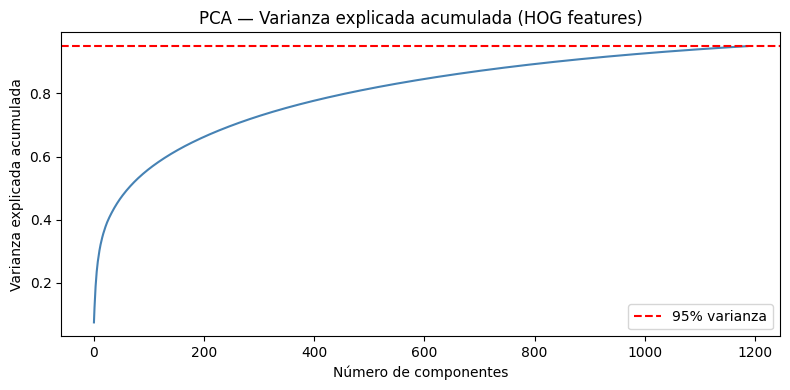

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_hog)
X_val_scaled   = scaler.transform(X_val_hog)
X_test_scaled  = scaler.transform(X_test_hog)

pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca   = pca.transform(X_val_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f"Componentes retenidas: {pca.n_components_} "
      f"(de {X_train_scaled.shape[1]} originales)")
print(f"Varianza explicada acumulada: {pca.explained_variance_ratio_.sum():.3f}")

# Gráfico de varianza explicada acumulada
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), color='steelblue')
plt.axhline(0.95, color='red', linestyle='--', label='95% varianza')
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("PCA — Varianza explicada acumulada (HOG features)")
plt.legend()
plt.tight_layout()
plt.show()

### 3. Compensar desbalanceo detectado en el EDA


El dataset presenta un desbalanceo entre las clases NORMAL y PNEUMONIA, con una proporción aproximada de 2.89:1.

Para abordar este problema, calculamos **pesos de clase balanceados** que serán utilizados por los modelos.

Esto asegura que el modelo no favorezca la clase mayoritaria y preste suficiente atención a la clase minoritaria (PNEUMONIA).

In [ ]:
cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight_dict = dict(enumerate(cw))
print(f"Class weights: {class_weight_dict}")

Class weights: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


## Modelos ML

Entrenamos tres modelos clásicos de Machine Learning: **Regresión Logística**, **SVM lineal** y **Random Forest**.
Estos modelos se seleccionaron por su capacidad para manejar problemas de clasificación binaria y su compatibilidad con datos transformados mediante PCA.

Para evaluar el rendimiento, utilizamos métricas como **AUC-ROC** y **recall** de la clase PNEUMONIA.
Estas métricas son críticas en un contexto clínico, donde los falsos negativos deben minimizarse.

In [ ]:
models_ml = {
    "Logistic Regression": LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42),

    "LinearSVC": LinearSVC(
        class_weight='balanced', max_iter=2000, random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        n_jobs=-1, random_state=42),
}

results = {}

for name, model in models_ml.items():
    print(f"\n{'='*50}")
    print(f"  Entrenando: {name}")
    print(f"{'='*50}")

    model.fit(X_train_pca, y_train)
    y_pred = model.predict(X_test_pca)

    # Para AUC necesitamos probabilidades o decision scores
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_pca)[:, 1]
    else:
        y_score = model.decision_function(X_test_pca)

    auc = roc_auc_score(y_test, y_score)
    report = classification_report(y_pred=y_pred, y_true=y_test,
                                   target_names=CLASSES, output_dict=True)

    results[name] = {
        "model":   model,
        "y_pred":  y_pred,
        "y_score": y_score,
        "auc":     auc,
        "report":  report,
    }

    print(classification_report(y_test, y_pred, target_names=CLASSES))
    print(f"AUC-ROC: {auc:.4f}")


  Entrenando: Logistic Regression
              precision    recall  f1-score   support

      NORMAL       0.98      0.43      0.60       234
   PNEUMONIA       0.74      0.99      0.85       390

    accuracy                           0.78       624
   macro avg       0.86      0.71      0.72       624
weighted avg       0.83      0.78      0.76       624

AUC-ROC: 0.9271

  Entrenando: LinearSVC
              precision    recall  f1-score   support

      NORMAL       0.88      0.52      0.65       234
   PNEUMONIA       0.77      0.96      0.85       390

    accuracy                           0.79       624
   macro avg       0.83      0.74      0.75       624
weighted avg       0.81      0.79      0.78       624

AUC-ROC: 0.8773

  Entrenando: Random Forest
              precision    recall  f1-score   support

      NORMAL       1.00      0.04      0.08       234
   PNEUMONIA       0.64      1.00      0.78       390

    accuracy                           0.64       624
   macr

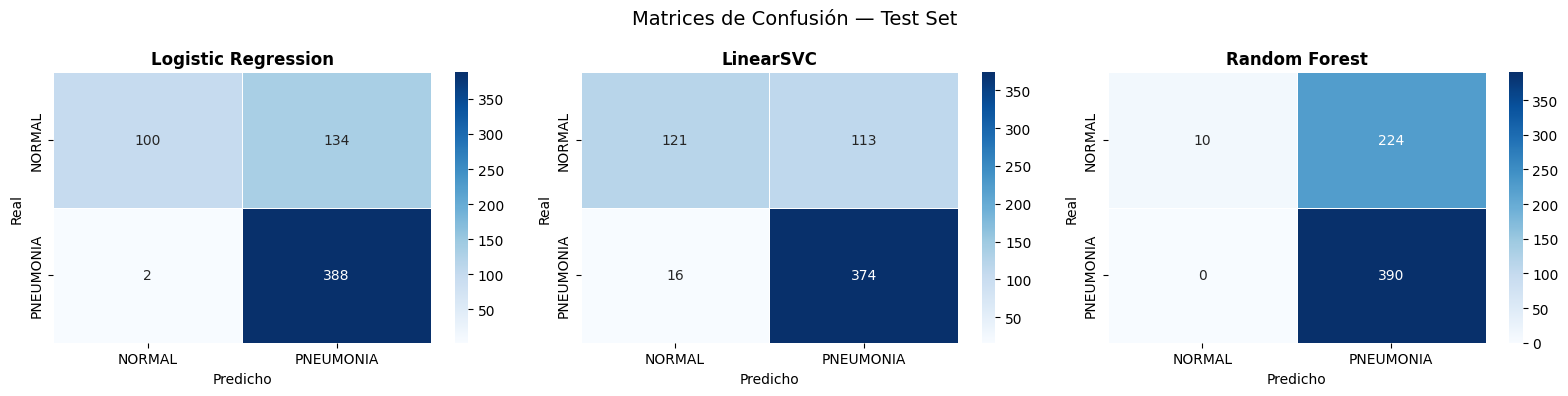

In [ ]:
# MATRICES DE CONFUSIÓN 
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                xticklabels=CLASSES, yticklabels=CLASSES,
                cmap='Blues', linewidths=0.5)
    ax.set_title(f"{name}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")

plt.suptitle("Matrices de Confusión — Test Set", fontsize=14)
plt.tight_layout()
plt.show()

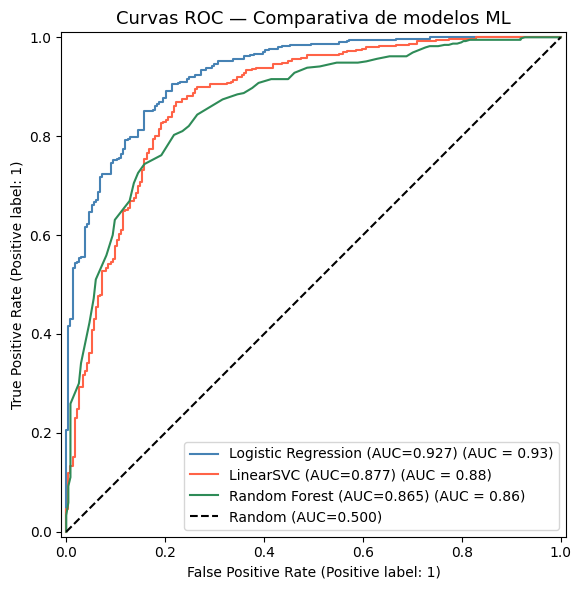

In [ ]:
# CURVAS ROC COMPARATIVA
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['steelblue', 'tomato', 'seagreen']

for (name, res), color in zip(results.items(), colors):
    RocCurveDisplay.from_predictions(
        y_test, res["y_score"],
        name=f"{name} (AUC={res['auc']:.3f})",
        ax=ax, color=color
    )

ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.500)')
ax.set_title("Curvas ROC — Comparativa de modelos ML", fontsize=13)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

##  Análisis de Resultados — ML Clásico

### Contexto clínico
Como hemos comentado anteriormente, en detección de pneumonía, un **Falso Negativo (FN)** equivale a un paciente enfermo
clasificado como sano, el error más grave clínicamente. Por tanto, la métrica
prioritaria es el **recall de PNEUMONIA** y el **AUC-ROC**, por encima de la accuracy global.


### Resultados por modelo

**Logistic Regression** es el mejor modelo con **AUC-ROC = 0.927**.
Consigue un recall de PNEUMONIA de **0.99**, dejando escapar solo **2 enfermos de 390**, clínicamente muy bueno. El precio es un recall de NORMAL bajo (0.43):
134 falsos positivos (sanos clasificados como enfermos). En un contexto de cribado
médico, este trade-off es aceptable: mejor sobrediagnosticar que pasar por alto una neumonía.

**LinearSVC** obtiene **AUC-ROC = 0.877** con un comportamiento más equilibrado:
recall PNEUMONIA de **0.96** (16 FN) y recall NORMAL de 0.52 (113 FP).
Reduce los falsos positivos respecto a Logistic Regression, pero a costa de perder
sensibilidad sobre los pacientes enfermos, un trade-off menos favorable en este contexto.

**Random Forest** es el peor modelo para este problema a pesar de su AUC-ROC de 0.865.
Su recall de NORMAL es de apenas **0.04**, prácticamente clasifica todo como PNEUMONIA,
con 224 falsos positivos y un F1-NORMAL de 0.08. Aunque no pierde ningún enfermo (0 FN),
su incapacidad para distinguir entre clases lo hace inviable en la práctica.

---

### Tabla resumen

| Modelo | AUC-ROC | Recall PNEUMONIA | FN (enfermos perdidos) | FP (sanos mal clasificados) |
|---|---|---|---|---|
| **Logistic Regression** | **0.927** | **0.99** | **2** | 134 |
| LinearSVC | 0.877 | 0.96 | 16 | 113 |
| Random Forest | 0.865 | 1.00 | 0 | 224 |

---

### Conclusión

El mejor modelo ML es **Logistic Regression con HOG + PCA**, con solo 2 pacientes
con neumonía no detectados sobre 390. Esto establece el **baseline para los notebooks
de Deep Learning**: superar **AUC-ROC = 0.927** y mantener **recall PNEUMONIA ≥ 0.99**,
mejorando a la vez el F1-NORMAL para reducir la carga de falsos positivos sobre el sistema.